# 🚴 Exploration des données Vélib - Fichiers Parquet

Ce notebook explore les données brutes extraites de l'API Vélib et stockées en format Parquet.

## Objectifs
1. Charger et explorer les fichiers Parquet
2. Analyser la structure des données
3. Statistiques descriptives
4. Identifier les données manquantes
5. Visualisations exploratoires
6. Validation de la qualité des données

## 📦 1. Imports et Configuration

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
from datetime import datetime
import json
import warnings

warnings.filterwarnings('ignore')

# Configuration des visualisations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Options d'affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print("✅ Imports réussis")
print(f"Version Pandas: {pd.__version__}")
print(f"Version NumPy: {np.__version__}")

✅ Imports réussis
Version Pandas: 2.0.3
Version NumPy: 1.24.4


## 📂 2. Localiser les fichiers Parquet

In [31]:
# Chemin vers le data lake (ajustez selon votre montage)
DATA_LAKE_PATH = Path('/home/jovyan/data_lake/bronze/velib')

# Alternative si vous êtes en local
# DATA_LAKE_PATH = Path('../data_lake/bronze/velib')

print(f"Chemin du data lake: {DATA_LAKE_PATH}")
print(f"Existe: {DATA_LAKE_PATH.exists()}")

Chemin du data lake: /home/jovyan/data_lake/bronze/velib
Existe: True


In [32]:
# Lister tous les fichiers Parquet
parquet_files = list(DATA_LAKE_PATH.glob('**/*.parquet'))

print(f"📊 Nombre total de fichiers Parquet: {len(parquet_files)}")
print("\n📁 Premiers fichiers:")
for i, file in enumerate(parquet_files[:5], 1):
    file_size = file.stat().st_size / 1024  # en KB
    print(f"{i}. {file.name} ({file_size:.2f} KB)")

if len(parquet_files) > 5:
    print(f"... et {len(parquet_files) - 5} autres fichiers")

📊 Nombre total de fichiers Parquet: 9

📁 Premiers fichiers:
1. snapshot_20260211_101901.parquet (11.05 KB)
2. snapshot_20260211_100438.parquet (11.03 KB)
3. snapshot_20260211_101246.parquet (11.05 KB)
4. snapshot_20260211_101937.parquet (11.05 KB)
5. snapshot_20260211_101148.parquet (11.03 KB)
... et 4 autres fichiers


In [33]:
# Explorer la structure des répertoires
print("📁 Structure du data lake:\n")
for file in sorted(parquet_files[:10]):
    # Extraire la date et l'heure du chemin
    parts = file.parts
    print(f"  {'/'.join(parts[-3:])}")

📁 Structure du data lake:

  ingestion_date=2026-02-11/hour=10/snapshot_20260211_100438.parquet
  ingestion_date=2026-02-11/hour=10/snapshot_20260211_101148.parquet
  ingestion_date=2026-02-11/hour=10/snapshot_20260211_101246.parquet
  ingestion_date=2026-02-11/hour=10/snapshot_20260211_101348.parquet
  ingestion_date=2026-02-11/hour=10/snapshot_20260211_101901.parquet
  ingestion_date=2026-02-11/hour=10/snapshot_20260211_101937.parquet
  ingestion_date=2026-02-11/hour=10/snapshot_20260211_102352.parquet
  ingestion_date=2026-02-11/hour=20/snapshot_20260211_203040.parquet
  ingestion_date=2026-02-11/hour=21/snapshot_20260211_213955.parquet


## 🔍 3. Charger et explorer UN fichier

In [46]:
# Charger le premier (ou le plus récent) fichier
if parquet_files:
    sample_file = parquet_files[8]  # Ou sorted(parquet_files)[-1] pour le plus récent
    print(f"📄 Fichier chargé: {sample_file.name}")
    
    df_sample = pd.read_parquet(sample_file)
    print(f"✅ DataFrame chargé avec {len(df_sample)} lignes et {len(df_sample.columns)} colonnes")
else:
    print("❌ Aucun fichier Parquet trouvé")

📄 Fichier chargé: snapshot_20260211_213955.parquet
✅ DataFrame chargé avec 1506 lignes et 17 colonnes


In [47]:
# Aperçu des premières lignes
print("📊 Premières lignes du DataFrame:\n")
df_sample.head()

📊 Premières lignes du DataFrame:



,stationcode,name,is_installed,capacity,numdocksavailable,numbikesavailable,mechanical,ebike,is_renting,is_returning,duedate,coordonnees_geo,nom_arrondissement_communes,code_insee_commune,station_opening_hours,ingestion_timestamp,snapshot_id
0,16107,Benjamin Godard - Victor Hugo,OUI,35,23,11,4,7,OUI,OUI,2026-02-11 20:11:53+00:00,"b'\x01\x01\x00\x00\x00M\x84\rO\xaf4\x02@,\xf2\...",Paris,75056,None,2026-02-11T21:39:55.974965+01:00,20260211_213955
1,40001,Hôpital Mondor,OUI,28,10,18,10,8,OUI,OUI,2026-02-11 20:13:35+00:00,b'\x01\x01\x00\x00\x00\xbcI\x8b#E\xa1\x03@\xce...,Créteil,94028,None,2026-02-11T21:39:55.974965+01:00,20260211_213955
2,32304,Charcot - Benfleet,OUI,28,18,9,3,6,OUI,OUI,2026-02-11 20:13:38+00:00,b'\x01\x01\x00\x00\x00\xfal\xcda1\x86\x03@\xb5...,Romainville,93063,None,2026-02-11T21:39:55.974965+01:00,20260211_213955
3,9020,Toudouze - Clauzel,OUI,21,13,6,3,3,OUI,OUI,2026-02-11 20:06:48+00:00,b'\x01\x01\x00\x00\x00\x01\x00\x00\xd8\xe9\xb2...,Paris,75056,None,2026-02-11T21:39:55.974965+01:00,20260211_213955
4,14111,Cassini - Denfert-Rochereau,OUI,25,19,5,1,4,OUI,OUI,2026-02-11 20:11:36+00:00,b'\x01\x01\x00\x00\x00\xca\xff\xffT3\xb0\x02@\...,Paris,75056,None,2026-02-11T21:39:55.974965+01:00,20260211_213955


In [36]:
# Informations sur le DataFrame
print("ℹ️  Informations sur le DataFrame:\n")
df_sample.info()

ℹ️  Informations sur le DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   stationcode                  5 non-null      object
 1   name                         5 non-null      object
 2   is_installed                 5 non-null      object
 3   capacity                     5 non-null      int64 
 4   numdocksavailable            5 non-null      int64 
 5   numbikesavailable            5 non-null      int64 
 6   mechanical                   5 non-null      int64 
 7   ebike                        5 non-null      int64 
 8   is_renting                   5 non-null      object
 9   is_returning                 5 non-null      object
 10  duedate                      5 non-null      object
 11  coordonnees_geo              5 non-null      object
 12  nom_arrondissement_communes  5 non-null      object
 13  cod

In [37]:
# Types de données
print("📋 Types de données:\n")
df_sample.dtypes

📋 Types de données:



stationcode                    object
name                           object
is_installed                   object
capacity                        int64
numdocksavailable               int64
numbikesavailable               int64
mechanical                      int64
ebike                           int64
is_renting                     object
is_returning                   object
duedate                        object
coordonnees_geo                object
nom_arrondissement_communes    object
code_insee_commune             object
station_opening_hours          object
ingestion_timestamp            object
snapshot_id                    object
dtype: object

In [38]:
# Colonnes disponibles
print(f"📝 Colonnes ({len(df_sample.columns)}):\n")
for i, col in enumerate(df_sample.columns, 1):
    print(f"{i:2d}. {col}")

📝 Colonnes (17):

 1. stationcode
 2. name
 3. is_installed
 4. capacity
 5. numdocksavailable
 6. numbikesavailable
 7. mechanical
 8. ebike
 9. is_renting
10. is_returning
11. duedate
12. coordonnees_geo
13. nom_arrondissement_communes
14. code_insee_commune
15. station_opening_hours
16. ingestion_timestamp
17. snapshot_id


## 📊 4. Statistiques descriptives

In [11]:
# Statistiques pour colonnes numériques
print("📈 Statistiques descriptives (colonnes numériques):\n")
df_sample.describe()

📈 Statistiques descriptives (colonnes numériques):



,capacity,numdocksavailable,numbikesavailable,mechanical,ebike
count,5.00,5.00,5.00,5.00,5.00
mean,28.00,16.00,11.00,3.80,7.20
std,18.53,20.63,4.85,4.44,1.30
min,12.00,0.00,7.00,0.00,6.00
25%,21.00,2.00,8.00,1.00,6.00
50%,22.00,11.00,9.00,2.00,7.00
75%,25.00,16.00,12.00,5.00,8.00
max,60.00,51.00,19.00,11.00,9.00


In [12]:
# Statistiques pour colonnes catégorielles
print("📊 Statistiques descriptives (colonnes catégorielles):\n")
df_sample.describe(include=['object', 'bool'])

📊 Statistiques descriptives (colonnes catégorielles):



,stationcode,name,is_installed,is_renting,is_returning,duedate,coordonnees_geo,nom_arrondissement_communes,code_insee_commune,station_opening_hours,ingestion_timestamp,snapshot_id
count,5,5,5,5,5,5,5,5,5,0,5,5
unique,5,5,1,1,1,5,5,2,2,0,1,1
top,9020,Toudouze - Clauzel,OUI,OUI,OUI,2026-02-11T09:13:56+00:00,"{'lat': 48.87929591733507, 'lon': 2.3373600840...",Paris,75056,NaN,2026-02-11T10:19:01.001499+00:00,20260211_101901
freq,1,1,5,5,5,1,1,4,4,NaN,5,5


In [13]:
# Nombre de valeurs uniques par colonne
print("🔢 Nombre de valeurs uniques par colonne:\n")
unique_counts = df_sample.nunique().sort_values(ascending=False)
print(unique_counts)

🔢 Nombre de valeurs uniques par colonne:



TypeError: unhashable type: 'dict'

## 🕳️ 5. Analyse des valeurs manquantes

In [14]:
# Compter les valeurs manquantes
missing = df_sample.isnull().sum()
missing_pct = (missing / len(df_sample)) * 100

missing_df = pd.DataFrame({
    'Colonne': missing.index,
    'Valeurs manquantes': missing.values,
    'Pourcentage': missing_pct.values
})

missing_df = missing_df[missing_df['Valeurs manquantes'] > 0].sort_values('Valeurs manquantes', ascending=False)

if len(missing_df) > 0:
    print("⚠️  Colonnes avec valeurs manquantes:\n")
    print(missing_df.to_string(index=False))
else:
    print("✅ Aucune valeur manquante détectée")

⚠️  Colonnes avec valeurs manquantes:

              Colonne  Valeurs manquantes  Pourcentage
station_opening_hours                   5       100.00


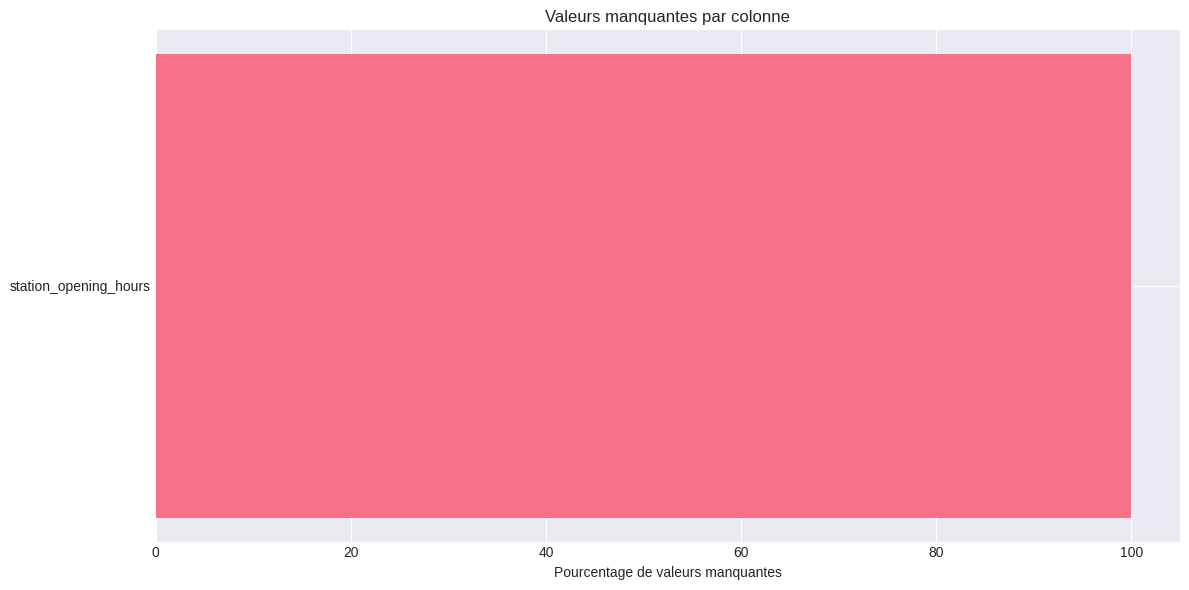

In [15]:
# Visualisation des valeurs manquantes
if len(missing_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.barh(missing_df['Colonne'], missing_df['Pourcentage'])
    plt.xlabel('Pourcentage de valeurs manquantes')
    plt.title('Valeurs manquantes par colonne')
    plt.tight_layout()
    plt.show()

## 🔍 6. Exploration des colonnes clés

In [16]:
# Adapter selon les vraies colonnes de votre dataset
# Exemple de colonnes probables :

# Si vous avez une colonne 'stationcode' ou similaire
if 'stationcode' in df_sample.columns:
    print(f"📍 Nombre de stations uniques: {df_sample['stationcode'].nunique()}")
    print(f"📍 Exemples de stations: {df_sample['stationcode'].head(10).tolist()}")

# Si vous avez des colonnes de disponibilité
availability_cols = [col for col in df_sample.columns if 'available' in col.lower() or 'capacity' in col.lower()]
if availability_cols:
    print(f"\n📊 Colonnes de disponibilité trouvées: {availability_cols}")
    print("\nStatistiques:")
    print(df_sample[availability_cols].describe())

📍 Nombre de stations uniques: 5
📍 Exemples de stations: ['9020', '14111', '14014', '32017', '8026']

📊 Colonnes de disponibilité trouvées: ['capacity', 'numdocksavailable', 'numbikesavailable']

Statistiques:
       capacity  numdocksavailable  numbikesavailable
count      5.00               5.00               5.00
mean      28.00              16.00              11.00
std       18.53              20.63               4.85
min       12.00               0.00               7.00
25%       21.00               2.00               8.00
50%       22.00              11.00               9.00
75%       25.00              16.00              12.00
max       60.00              51.00              19.00


In [17]:
# Explorer les champs nested (si JSON/dict)
# Adapter selon votre structure réelle

for col in df_sample.columns:
    if df_sample[col].dtype == 'object':
        # Vérifier si c'est du JSON
        sample_value = df_sample[col].iloc[0]
        if isinstance(sample_value, (dict, list)):
            print(f"\n🔍 Colonne '{col}' contient des structures imbriquées:")
            print(f"Type: {type(sample_value)}")
            print(f"Exemple:\n{sample_value}")


🔍 Colonne 'coordonnees_geo' contient des structures imbriquées:
Type: <class 'dict'>
Exemple:
{'lat': 48.87929591733507, 'lon': 2.3373600840568547}


## 📍 7. Analyse géographique (si coordonnées disponibles)

In [18]:
# Identifier les colonnes de coordonnées
geo_cols = [col for col in df_sample.columns if any(x in col.lower() for x in ['lat', 'lon', 'coord', 'geo'])]

if geo_cols:
    print(f"🗺️  Colonnes géographiques trouvées: {geo_cols}")
    
    # Si vous avez des coordonnées sous forme de colonnes séparées
    # Ajustez selon votre structure
    if 'coordonnees_geo' in df_sample.columns:
        # Si c'est un dict avec lat/lon
        sample_coord = df_sample['coordonnees_geo'].iloc[0]
        print(f"\nExemple de coordonnées: {sample_coord}")
else:
    print("ℹ️  Aucune colonne géographique évidente détectée")

🗺️  Colonnes géographiques trouvées: ['coordonnees_geo']

Exemple de coordonnées: {'lat': 48.87929591733507, 'lon': 2.3373600840568547}


In [19]:
# Si vous avez des colonnes lat/lon extraites ou à extraire
# Exemple de visualisation simple (à adapter)

# Décommenter et adapter si vous avez des colonnes lat/lon
# if 'latitude' in df_sample.columns and 'longitude' in df_sample.columns:
#     plt.figure(figsize=(12, 8))
#     plt.scatter(df_sample['longitude'], df_sample['latitude'], alpha=0.5, s=10)
#     plt.xlabel('Longitude')
#     plt.ylabel('Latitude')
#     plt.title('Répartition géographique des stations Vélib')
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

## 📊 8. Visualisations des données de disponibilité

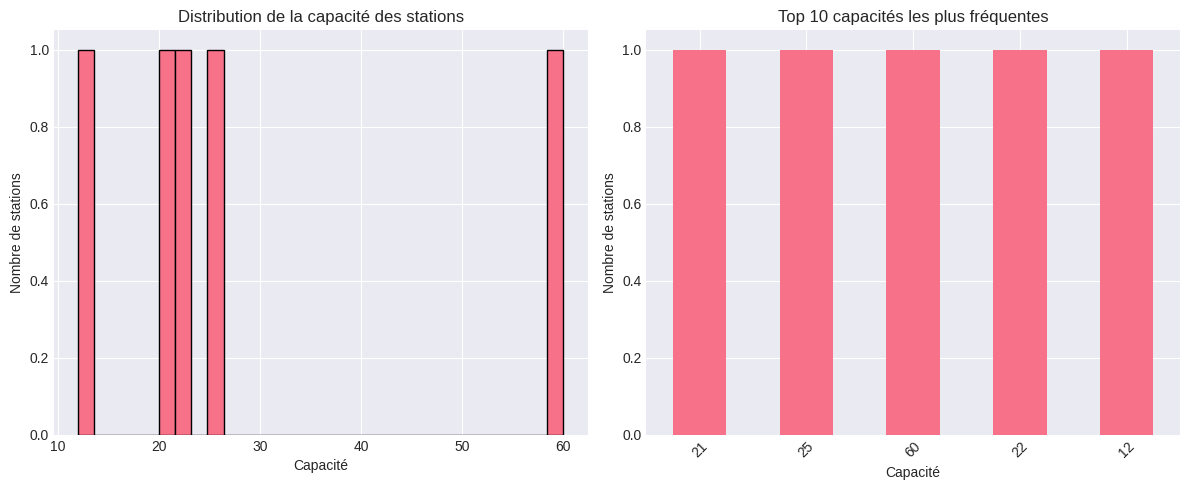

In [20]:
# Distribution de la capacité des stations (si colonne existe)
if 'capacity' in df_sample.columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    df_sample['capacity'].hist(bins=30, edgecolor='black')
    plt.xlabel('Capacité')
    plt.ylabel('Nombre de stations')
    plt.title('Distribution de la capacité des stations')
    
    plt.subplot(1, 2, 2)
    df_sample['capacity'].value_counts().head(10).plot(kind='bar')
    plt.xlabel('Capacité')
    plt.ylabel('Nombre de stations')
    plt.title('Top 10 capacités les plus fréquentes')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

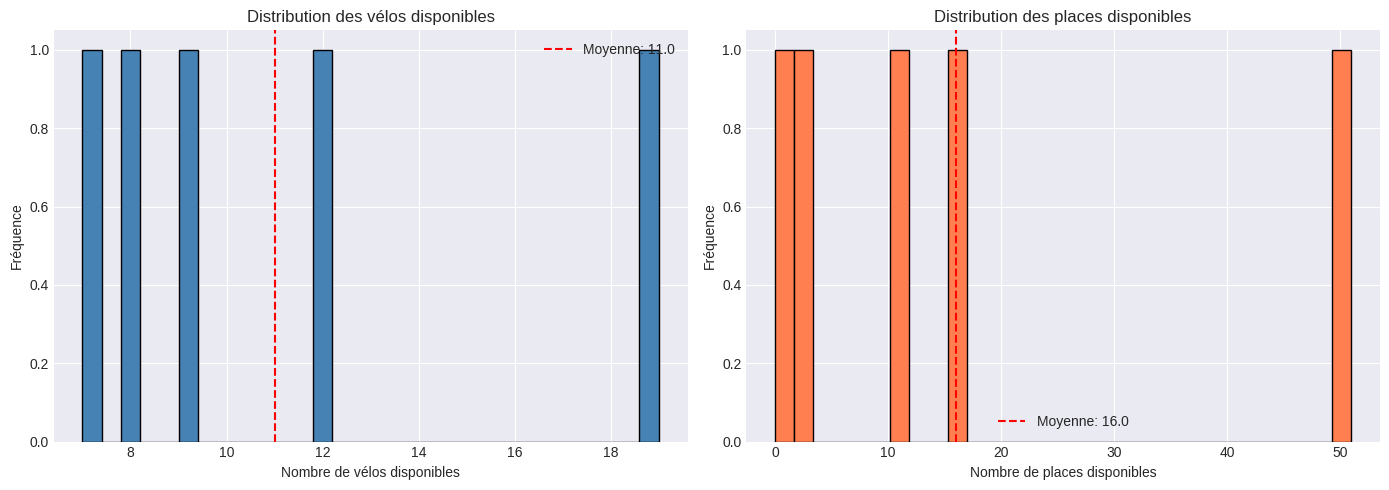

In [21]:
# Vélos et places disponibles (si colonnes existent)
if 'numbikesavailable' in df_sample.columns and 'numdocksavailable' in df_sample.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Vélos disponibles
    axes[0].hist(df_sample['numbikesavailable'], bins=30, edgecolor='black', color='steelblue')
    axes[0].set_xlabel('Nombre de vélos disponibles')
    axes[0].set_ylabel('Fréquence')
    axes[0].set_title('Distribution des vélos disponibles')
    axes[0].axvline(df_sample['numbikesavailable'].mean(), color='red', linestyle='--', label=f'Moyenne: {df_sample["numbikesavailable"].mean():.1f}')
    axes[0].legend()
    
    # Places disponibles
    axes[1].hist(df_sample['numdocksavailable'], bins=30, edgecolor='black', color='coral')
    axes[1].set_xlabel('Nombre de places disponibles')
    axes[1].set_ylabel('Fréquence')
    axes[1].set_title('Distribution des places disponibles')
    axes[1].axvline(df_sample['numdocksavailable'].mean(), color='red', linestyle='--', label=f'Moyenne: {df_sample["numdocksavailable"].mean():.1f}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

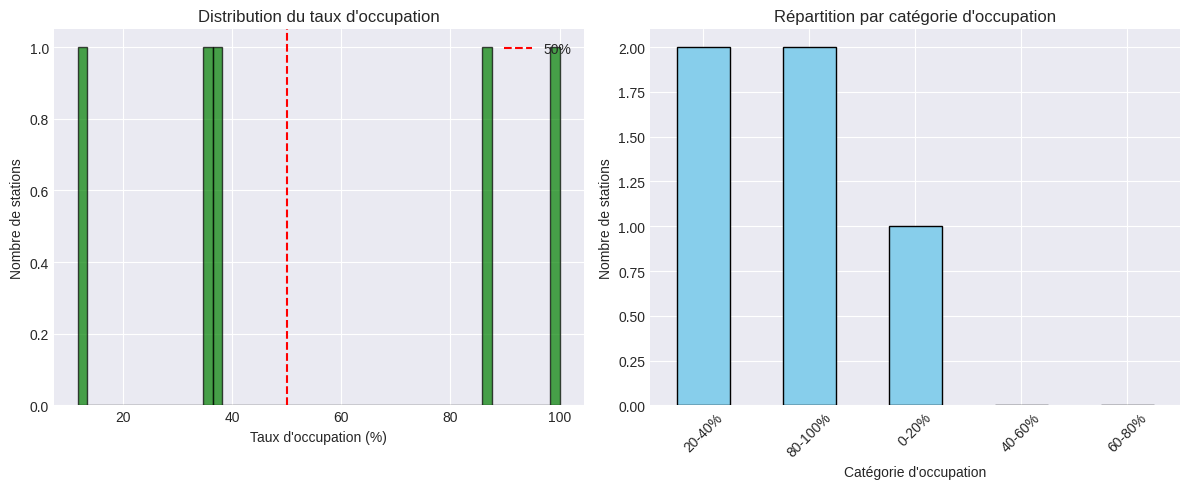


📊 Taux d'occupation moyen: 54.4%
📊 Taux d'occupation médian: 38.1%


In [22]:
# Taux d'occupation (si données disponibles)
if 'numbikesavailable' in df_sample.columns and 'capacity' in df_sample.columns:
    df_sample['taux_occupation'] = (df_sample['numbikesavailable'] / df_sample['capacity'] * 100)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    df_sample['taux_occupation'].hist(bins=50, edgecolor='black', color='green', alpha=0.7)
    plt.xlabel('Taux d\'occupation (%)')
    plt.ylabel('Nombre de stations')
    plt.title('Distribution du taux d\'occupation')
    plt.axvline(50, color='red', linestyle='--', label='50%')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    occupation_categories = pd.cut(df_sample['taux_occupation'], 
                                   bins=[0, 20, 40, 60, 80, 100], 
                                   labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])
    occupation_categories.value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.xlabel('Catégorie d\'occupation')
    plt.ylabel('Nombre de stations')
    plt.title('Répartition par catégorie d\'occupation')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Taux d'occupation moyen: {df_sample['taux_occupation'].mean():.1f}%")
    print(f"📊 Taux d'occupation médian: {df_sample['taux_occupation'].median():.1f}%")

## 🔄 9. Charger TOUS les fichiers (agrégation temporelle)

In [23]:
# Charger tous les fichiers Parquet
# ATTENTION: peut être lourd si beaucoup de fichiers

print(f"⏳ Chargement de {len(parquet_files)} fichiers...")

all_data = []
for file in parquet_files:
    df_temp = pd.read_parquet(file)
    all_data.append(df_temp)

df_all = pd.concat(all_data, ignore_index=True)

print(f"✅ {len(df_all)} lignes chargées au total")
print(f"📊 Shape: {df_all.shape}")
print(f"💾 Taille en mémoire: {df_all.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

⏳ Chargement de 7 fichiers...
✅ 35 lignes chargées au total
📊 Shape: (35, 17)
💾 Taille en mémoire: 0.03 MB


In [24]:
# Aperçu du dataset complet
df_all.head()

,stationcode,name,is_installed,capacity,numdocksavailable,numbikesavailable,mechanical,ebike,is_renting,is_returning,duedate,coordonnees_geo,nom_arrondissement_communes,code_insee_commune,station_opening_hours,ingestion_timestamp,snapshot_id
0,9020,Toudouze - Clauzel,OUI,21,11,8,2,6,OUI,OUI,2026-02-11T09:13:56+00:00,"{'lat': 48.87929591733507, 'lon': 2.3373600840...",Paris,75056,None,2026-02-11T10:19:01.001499+00:00,20260211_101901
1,14111,Cassini - Denfert-Rochereau,OUI,25,16,9,0,9,OUI,OUI,2026-02-11T09:14:19+00:00,"{'lat': 48.837525839067, 'lon': 2.3360354080796}",Paris,75056,None,2026-02-11T10:19:01.001499+00:00,20260211_101901
2,14014,Jourdan - Stade Charléty,OUI,60,51,7,1,6,OUI,OUI,2026-02-11T09:10:12+00:00,"{'lat': 48.819428333369, 'lon': 2.3433353751898}",Paris,75056,None,2026-02-11T10:19:01.001499+00:00,20260211_101901
3,32017,Basilique,OUI,22,2,19,11,8,OUI,OUI,2026-02-11T09:05:05+00:00,"{'lat': 48.93626891059109, 'lon': 2.3588666820...",Saint-Denis,93066,None,2026-02-11T10:19:01.001499+00:00,20260211_101901
4,8026,Messine - Place Du Pérou,OUI,12,0,12,5,7,OUI,OUI,2026-02-11T09:12:29+00:00,"{'lat': 48.875448033960744, 'lon': 2.315508019...",Paris,75056,None,2026-02-11T10:19:01.001499+00:00,20260211_101901


In [25]:
# Analyse temporelle (si vous avez un timestamp)
if 'ingestion_timestamp' in df_all.columns:
    # Convertir en datetime si nécessaire
    df_all['ingestion_timestamp'] = pd.to_datetime(df_all['ingestion_timestamp'])
    
    print("📅 Période couverte:")
    print(f"   Du: {df_all['ingestion_timestamp'].min()}")
    print(f"   Au: {df_all['ingestion_timestamp'].max()}")
    print(f"   Durée: {df_all['ingestion_timestamp'].max() - df_all['ingestion_timestamp'].min()}")
    
    # Nombre de snapshots
    if 'snapshot_id' in df_all.columns:
        print(f"\n📸 Nombre de snapshots: {df_all['snapshot_id'].nunique()}")

📅 Période couverte:
   Du: 2026-02-11 10:04:38.486690+00:00
   Au: 2026-02-11 10:23:52.262336+00:00
   Durée: 0 days 00:19:13.775646

📸 Nombre de snapshots: 7


## 📈 10. Analyse temporelle (évolution dans le temps)

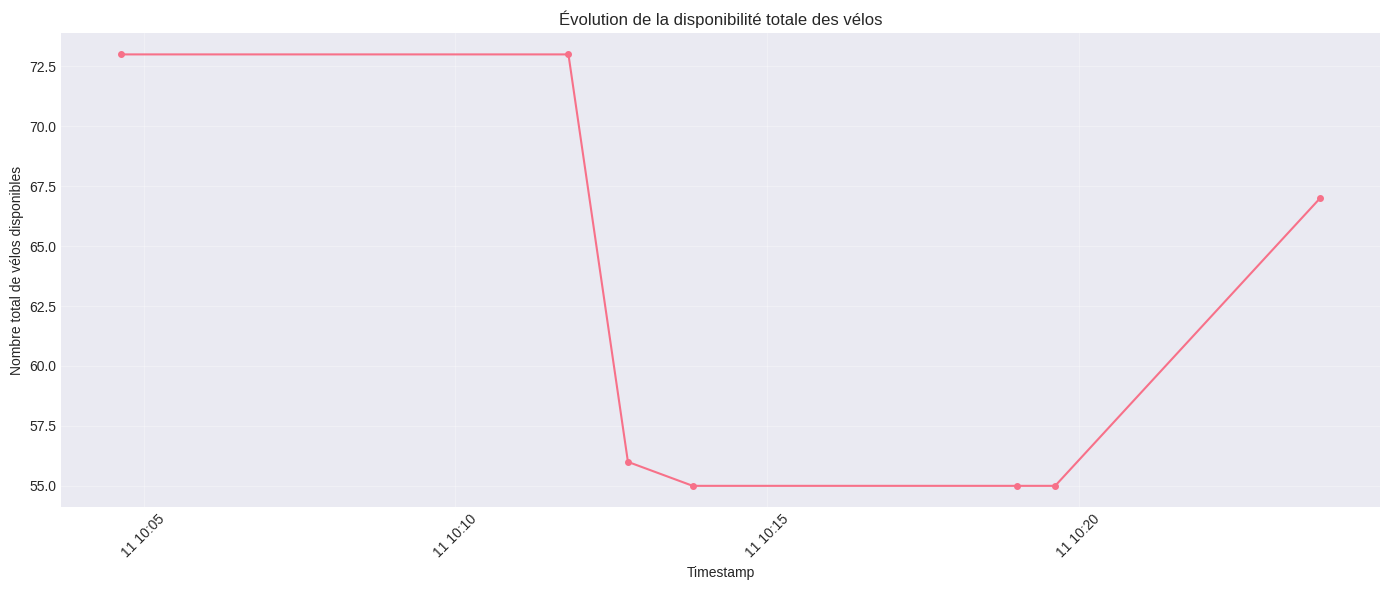

In [26]:
# Évolution du nombre de vélos disponibles dans le temps
if 'ingestion_timestamp' in df_all.columns and 'numbikesavailable' in df_all.columns:
    # Agrégation par timestamp
    time_agg = df_all.groupby('ingestion_timestamp').agg({
        'numbikesavailable': 'sum',
        'numdocksavailable': 'sum' if 'numdocksavailable' in df_all.columns else 'count'
    }).reset_index()
    
    plt.figure(figsize=(14, 6))
    plt.plot(time_agg['ingestion_timestamp'], time_agg['numbikesavailable'], marker='o', markersize=4)
    plt.xlabel('Timestamp')
    plt.ylabel('Nombre total de vélos disponibles')
    plt.title('Évolution de la disponibilité totale des vélos')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## ✅ 11. Validation de la qualité des données

In [27]:
# Tests de qualité
print("🔍 VALIDATION DE LA QUALITÉ DES DONNÉES\n")
print("=" * 60)

# Test 1: Doublons
duplicates = df_all.duplicated().sum()
print(f"\n1️⃣  Doublons: {duplicates}")
if duplicates > 0:
    print(f"   ⚠️  {duplicates} lignes dupliquées trouvées ({duplicates/len(df_all)*100:.2f}%)")
else:
    print("   ✅ Aucun doublon")

# Test 2: Valeurs manquantes globales
total_missing = df_all.isnull().sum().sum()
total_cells = df_all.shape[0] * df_all.shape[1]
print(f"\n2️⃣  Valeurs manquantes globales: {total_missing} / {total_cells} ({total_missing/total_cells*100:.2f}%)")

# Test 3: Cohérence (vélos + places = capacité)
if all(col in df_all.columns for col in ['numbikesavailable', 'numdocksavailable', 'capacity']):
    df_all['total_computed'] = df_all['numbikesavailable'] + df_all['numdocksavailable']
    incoherent = (df_all['total_computed'] != df_all['capacity']).sum()
    print(f"\n3️⃣  Cohérence (vélos + places = capacité): ")
    if incoherent > 0:
        print(f"   ⚠️  {incoherent} incohérences détectées ({incoherent/len(df_all)*100:.2f}%)")
    else:
        print("   ✅ Toutes les lignes sont cohérentes")

# Test 4: Valeurs négatives
numeric_cols = df_all.select_dtypes(include=[np.number]).columns
negative_counts = {}
for col in numeric_cols:
    neg = (df_all[col] < 0).sum()
    if neg > 0:
        negative_counts[col] = neg

print(f"\n4️⃣  Valeurs négatives:")
if negative_counts:
    for col, count in negative_counts.items():
        print(f"   ⚠️  {col}: {count} valeurs négatives")
else:
    print("   ✅ Aucune valeur négative détectée")

print("\n" + "=" * 60)

🔍 VALIDATION DE LA QUALITÉ DES DONNÉES



TypeError: unhashable type: 'dict'

## 💾 12. Sauvegarder un rapport d'exploration

In [28]:
# Créer un rapport JSON avec les insights clés
report = {
    "date_generation": datetime.now().isoformat(),
    "nombre_fichiers": len(parquet_files),
    "nombre_total_lignes": len(df_all),
    "nombre_colonnes": len(df_all.columns),
    "colonnes": list(df_all.columns),
    "periode": {
        "debut": str(df_all['ingestion_timestamp'].min()) if 'ingestion_timestamp' in df_all.columns else None,
        "fin": str(df_all['ingestion_timestamp'].max()) if 'ingestion_timestamp' in df_all.columns else None
    },
    "qualite": {
        "doublons": int(duplicates),
        "valeurs_manquantes_total": int(total_missing),
        "pourcentage_completude": float((1 - total_missing/total_cells) * 100)
    },
    "statistiques": df_all.describe().to_dict() if len(df_all) > 0 else {}
}

# Sauvegarder le rapport
report_path = DATA_LAKE_PATH.parent.parent / 'reports'
report_path.mkdir(exist_ok=True)
report_file = report_path / f'exploration_report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'

with open(report_file, 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print(f"✅ Rapport sauvegardé: {report_file}")

NameError: name 'duplicates' is not defined

## 🎯 13. Conclusions et prochaines étapes

In [29]:
print("📋 RÉSUMÉ DE L'EXPLORATION\n")
print("=" * 60)
print(f"✅ {len(parquet_files)} fichiers Parquet analysés")
print(f"✅ {len(df_all):,} lignes de données au total")
print(f"✅ {len(df_all.columns)} colonnes")

if 'stationcode' in df_all.columns:
    print(f"✅ {df_all['stationcode'].nunique()} stations uniques")

if 'ingestion_timestamp' in df_all.columns:
    print(f"✅ Période: {df_all['ingestion_timestamp'].min()} → {df_all['ingestion_timestamp'].max()}")

print("\n📌 PROCHAINES ÉTAPES:\n")
print("1. 🔧 Nettoyer et normaliser les données (Silver layer)")
print("2. 📊 Créer des agrégations (Gold layer)")
print("3. 🚀 Automatiser l'ingestion avec Airflow")
print("4. 🔄 Implémenter les transformations dbt")
print("5. 📈 Créer des dashboards de visualisation")
print("\n" + "=" * 60)

📋 RÉSUMÉ DE L'EXPLORATION

✅ 7 fichiers Parquet analysés
✅ 35 lignes de données au total
✅ 17 colonnes
✅ 9 stations uniques
✅ Période: 2026-02-11 10:04:38.486690+00:00 → 2026-02-11 10:23:52.262336+00:00

📌 PROCHAINES ÉTAPES:

1. 🔧 Nettoyer et normaliser les données (Silver layer)
2. 📊 Créer des agrégations (Gold layer)
3. 🚀 Automatiser l'ingestion avec Airflow
4. 🔄 Implémenter les transformations dbt
5. 📈 Créer des dashboards de visualisation

